# Day 6 - Supervised Machine Learning

## Baseline Logistic Regression Classification Model

### Project Objective

The objective of this project is to build a baseline supervised Machine
Learning classification model using Scikit-Learn.

The cleaned dataset from the Day 5 Weekend Project is used as the starting
dataset.

The project separates independent features (X) from the dependent target
variable (y), performs an 80/20 Train-Test split, trains a Logistic
Regression model, makes predictions on unseen testing data, and evaluates
the model using accuracy.

In [55]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv("cleaned_ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


## 1. Dataset Inspection

The dataset is inspected to understand its dimensions, columns, data
types, and available values before preparing it for Machine Learning.

In [57]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 26)


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  str    
 1   Order_Date        10000 non-null  str    
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  str    
 5   Season            10000 non-null  str    
 6   Customer_ID       10000 non-null  str    
 7   Customer_Gender   10000 non-null  str    
 8   Customer_Segment  10000 non-null  str    
 9   Region            10000 non-null  str    
 10  Country           10000 non-null  str    
 11  Category          10000 non-null  str    
 12  Sub_Category      10000 non-null  str    
 13  Product_Name      10000 non-null  str    
 14  Unit_Price        10000 non-null  float64
 15  Quantity          10000 non-null  int64  
 16  Discount          10000 non-null  float64
 17  Reven

In [59]:
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Year',
 'Month',
 'Quarter',
 'Season',
 'Customer_ID',
 'Customer_Gender',
 'Customer_Segment',
 'Region',
 'Country',
 'Category',
 'Sub_Category',
 'Product_Name',
 'Unit_Price',
 'Quantity',
 'Discount',
 'Revenue',
 'Cost',
 'Profit',
 'Profit_Margin_%',
 'Shipping_Cost',
 'Shipping_Method',
 'Shipping_Days',
 'Payment_Method',
 'Order_Status']

In [60]:
df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [61]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64

## 2. Target Variable

For this project, a suitable binary target variable must be selected.
The target variable represents the outcome that the classification model
will learn to predict.

In [62]:
df["Order_Status"].value_counts()

Order_Status
Delivered     6273
Returned      1857
Processing     962
Cancelled      908
Name: count, dtype: int64

In [63]:
df["Order_Status"].nunique()


4

In [64]:
df["Is_Delivered"] = (df["Order_Status"] == "Delivered").astype(int)

In [65]:
df["Is_Delivered"].value_counts()

Is_Delivered
1    6273
0    3727
Name: count, dtype: int64

## Binary Target Variable

The original `Order_Status` column contains four categories:
Delivered, Returned, Processing, and Cancelled.

Since this project requires binary classification, a new target variable
called `Is_Delivered` is created.

- 1 represents a Delivered order.
- 0 represents an order that was not Delivered.

This creates a binary classification problem suitable for Logistic Regression.

In [66]:
df["Is_Delivered"].value_counts()

Is_Delivered
1    6273
0    3727
Name: count, dtype: int64

In [67]:
df["Is_Delivered"].value_counts(normalize=True) * 100

Is_Delivered
1    62.73
0    37.27
Name: proportion, dtype: float64

In [68]:
df.dtypes


Order_ID                str
Order_Date              str
Year                  int64
Month                 int64
Quarter                 str
Season                  str
Customer_ID             str
Customer_Gender         str
Customer_Segment        str
Region                  str
Country                 str
Category                str
Sub_Category            str
Product_Name            str
Unit_Price          float64
Quantity              int64
Discount            float64
Revenue             float64
Cost                float64
Profit              float64
Profit_Margin_%     float64
Shipping_Cost       float64
Shipping_Method         str
Shipping_Days         int64
Payment_Method          str
Order_Status            str
Is_Delivered          int64
dtype: object

In [69]:
df["Is_Delivered"] = (df["Order_Status"] == "Delivered").astype(int)

df["Is_Delivered"].value_counts()

Is_Delivered
1    6273
0    3727
Name: count, dtype: int64

In [70]:
df.select_dtypes(include="object").columns.tolist()

C:\Users\usman\AppData\Local\Temp\ipykernel_3624\3671663173.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns.tolist()


['Order_ID',
 'Order_Date',
 'Quarter',
 'Season',
 'Customer_ID',
 'Customer_Gender',
 'Customer_Segment',
 'Region',
 'Country',
 'Category',
 'Sub_Category',
 'Product_Name',
 'Shipping_Method',
 'Payment_Method',
 'Order_Status']

In [71]:
df["Is_Delivered"] = (df["Order_Status"] == "Delivered").astype(int)

## 2. Creating the Binary Target Variable

The original `Order_Status` column contains four categories:
Delivered, Returned, Processing, and Cancelled.

Because this project requires binary classification, a new target variable
called `Is_Delivered` is created.

- 1 represents a Delivered order.
- 0 represents an order that was not Delivered.

This allows the problem to be treated as a binary classification task.

In [72]:
df["Is_Delivered"].value_counts()

Is_Delivered
1    6273
0    3727
Name: count, dtype: int64

In [73]:
print("Target variable:", "Is_Delivered")
print("Number of classes:", df["Is_Delivered"].nunique())

Target variable: Is_Delivered
Number of classes: 2


## 3. Preparing the Features

The original `Order_Status` column is removed because it was used to create
the binary target `Is_Delivered`.

Identifier columns such as `Order_ID` and `Customer_ID` are also removed
because they do not represent useful predictive characteristics.

`Order_Date` is removed for this baseline model because date feature
engineering is outside the scope of this classification task.

In [74]:
X = df.drop(
    columns=[
        "Is_Delivered",
        "Order_Status",
        "Order_ID",
        "Customer_ID",
        "Order_Date"
    ]
)

y = df["Is_Delivered"]

In [75]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 22)
y shape: (10000,)


In [76]:
print("X columns:")
print(X.columns.tolist())

X columns:
['Year', 'Month', 'Quarter', 'Season', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method']


In [77]:
print("Target values:")
print(y.value_counts())

Target values:
Is_Delivered
1    6273
0    3727
Name: count, dtype: int64


## X and y

`X` contains the independent variables, which are the input features used
by the Machine Learning model.

`y` contains the dependent variable, which is the outcome that the model
attempts to predict.

In this project:

- X = customer, product, sales, shipping, and payment features
- y = Is_Delivered

## 4. Train-Test Split

The dataset is divided into training and testing sets before fitting any
data-dependent transformation.

80% of the observations are used for training and 20% are reserved for
testing.

The testing data remains unseen during model training.

A random_state of 42 is used to make the result reproducible.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [79]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (8000, 22)
X_test : (2000, 22)
y_train: (8000,)
y_test : (2000,)


In [80]:
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


Training target distribution:
Is_Delivered
1    5018
0    2982
Name: count, dtype: int64

Testing target distribution:
Is_Delivered
1    1255
0     745
Name: count, dtype: int64


In [81]:
categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_columns = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numeric_columns)

Categorical columns:
['Quarter', 'Season', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Shipping_Method', 'Payment_Method']

Numerical columns:
['Year', 'Month', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Days']


C:\Users\usman\AppData\Local\Temp\ipykernel_3624\3885883252.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(


In [82]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [83]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt
import seaborn as sns

## 5. One-Hot Encoding

The dataset contains categorical variables that cannot be directly used
by Logistic Regression.

One-Hot Encoding converts categorical variables into numerical columns.

The encoder is fitted only on the training data and then used to transform
both the training and testing data.

This prevents information from the testing dataset from influencing the
encoding process.

In [84]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [85]:
X_train_encoded = preprocessor.fit_transform(X_train)

In [86]:
preprocessor.fit_transform(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 217300 stored elements and shape (10000, 147)>

In [87]:
X_test_encoded = preprocessor.transform(X_test)

In [88]:
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

Encoded training shape: (8000, 147)
Encoded testing shape : (2000, 147)


## 6. Logistic Regression Baseline Model

Logistic Regression is a supervised Machine Learning algorithm commonly
used for classification problems.

It estimates the probability of an observation belonging to a class.

In this project, it is used as the baseline model to predict whether an
order was delivered.

In [89]:
model = LogisticRegression(max_iter=1000)

In [90]:
model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

In [91]:
from sklearn.preprocessing import StandardScaler

In [92]:
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [93]:
model = LogisticRegression(
    max_iter=5000,
    solver="liblinear",
    random_state=42
)

In [94]:
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (8000, 147)
Testing data shape: (2000, 147)


In [95]:
model = LogisticRegression(
    max_iter=10000,
    solver="liblinear",
    random_state=42
)

model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [96]:
y_pred = model.predict(X_test_scaled)

In [97]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Baseline Logistic Regression Accuracy:", accuracy)
print("Baseline Logistic Regression Accuracy (%):", round(accuracy * 100, 2), "%")

Baseline Logistic Regression Accuracy: 0.6225
Baseline Logistic Regression Accuracy (%): 62.25 %


## Model Accuracy

The baseline Logistic Regression model achieved an accuracy of **62.25%** on the unseen test dataset.

This means that the model correctly classified approximately **62.25% of the test observations**.

The accuracy was calculated using the predictions made on `X_test` and the actual target values in `y_test`.

```python
accuracy = accuracy_score(y_test, y_pred)

In [98]:
y_pred = model.predict(X_test_scaled)

In [99]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Baseline Logistic Regression Accuracy:", accuracy)
print("Baseline Logistic Regression Accuracy (%):", round(accuracy * 100, 2), "%")

Baseline Logistic Regression Accuracy: 0.6225
Baseline Logistic Regression Accuracy (%): 62.25 %


## Model Performance

The baseline Logistic Regression model achieved an accuracy of **62.25%**
on the unseen test dataset.

This means the model correctly classified approximately 62.25% of the
test observations.

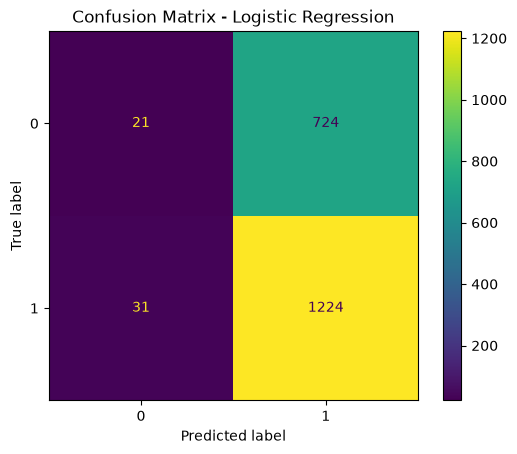

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()